
# Solar Activity Since 1755 — versão circular com curvas radiais

**Notebook autoral:** Andre L. Belem & F.R.I.D.A.Y.  
**Objetivo:** construir uma versão em Python/Jupyter de uma figura inspirada no gráfico circular dos ciclos solares, substituindo as “pétalas” por **curvas radiais** mais próximas de uma série temporal convencional.

---

## Ideia central

A proposta visual deste notebook é:

- manter a **organização circular** dos ciclos solares;
- substituir a geometria de “pétala” por uma **curva unidirecional** (como um pequeno gráfico de linha);
- usar **cores quentes** para representar a intensidade do número de manchas solares;
- preservar a leitura de cada ciclo como uma entidade independente;
- produzir uma visualização com estética forte, mas com leitura mais científica.

## O que este notebook faz

1. baixa (ou lê localmente) a série mensal do **SILSO**;
2. organiza os dados por **ciclo solar**;
3. aplica uma **suavização opcional**;
4. projeta cada ciclo em um arranjo circular;
5. desenha as curvas com coloração por intensidade;
6. salva a figura em **PNG**, **SVG** e **PDF**.

## Observação importante

Este notebook foi pensado para ser **didático, comentado e ajustável**. Ele privilegia clareza e flexibilidade em vez de compactação extrema do código.



## 1. Bibliotecas

Nesta etapa importamos as bibliotecas principais:

- **numpy**: operações numéricas;
- **pandas**: leitura e manipulação dos dados mensais;
- **matplotlib**: construção da figura;
- **requests**: download opcional do arquivo do SILSO;
- **pathlib**: organização dos caminhos de entrada e saída.


In [53]:

from pathlib import Path
import io
import math
import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable



## 2. Configuração geral

Nesta célula centralizamos os parâmetros mais importantes do notebook.

### Parâmetros científicos / de dados
- `SMOOTHING_WINDOW`: janela de suavização (13 meses é uma escolha clássica para séries solares);
- `USE_SMOOTHED_SERIES`: se `True`, a figura usa a série suavizada; caso contrário usa a série mensal original;
- `NORMALIZE_CYCLE_LENGTH`: se `True`, todos os ciclos ocupam o mesmo comprimento radial, facilitando comparação de forma. Se `False`, o comprimento radial reflete a duração relativa do ciclo.

### Parâmetros gráficos
- `INNER_RADIUS`: raio interno onde os ciclos começam;
- `RADIAL_LENGTH`: extensão radial máxima dos ciclos;
- `AMPLITUDE_SCALE`: escala da “altura” transversal da curva;
- `FIGSIZE`: tamanho da figura.


In [54]:
# ------------------------------
# Dados e caminhos
# ------------------------------
SILSO_URL = "https://www.sidc.be/SILSO/DATA/SN_m_tot_V2.0.txt"
LOCAL_SILSO_FILE = None  # Exemplo: Path("./SN_m_tot_V2.0.txt")

OUTPUT_DIR = Path("outputs_solar_cycles")
OUTPUT_DIR.mkdir(exist_ok=True)

# ------------------------------
# Parâmetros de pré-processamento
# ------------------------------
SMOOTHING_WINDOW = 13
USE_SMOOTHED_SERIES = True
NORMALIZE_CYCLE_LENGTH = True

# ------------------------------
# Parâmetros geométricos / visuais
# ------------------------------
FIGSIZE = (12, 16)
INNER_RADIUS = 0.18
RADIAL_LENGTH = 0.62
AMPLITUDE_SCALE = 0.11
GUIDE_EXTRA = 0.08
LABEL_RADIUS = INNER_RADIUS + RADIAL_LENGTH + GUIDE_EXTRA + 0.05
CENTER_DISC_RADIUS = 0.11

TITLE = "Solar Activity Since 1755"
SUBTITLE = "Monthly mean total sunspot number arranged by solar cycle"
COLORBAR_LABEL = "Sunspot Number (Monthly Mean)"
AUTHOR_LINE = "Andre L. Belem · F.R.I.D.A.Y."
DATA_NOTE = "Data: SILSO (Royal Observatory of Belgium) · Graphic concept adapted and redrawn in Python"

BACKGROUND_COLOR = "#020612"
FOREGROUND_COLOR = "#f2f2f2"
GUIDE_COLOR = "#94a3b8"
DATA_NOTE_COLOR = "#9ca3af"

# Escala de cor quente, inspirada na ideia da figura original,
# mas adaptada para uma leitura mais limpa.
SOLAR_CMAP = LinearSegmentedColormap.from_list(
    "solar_custom",
    ["#fff7cc", "#ffd166", "#ff9f43", "#ff5a36", "#e31a1c", "#8b0029"]
)

# Limites para a barra de cor.
# O valor 300 é consistente com números mensais altos de sunspot.
COLOR_MIN = 0
COLOR_MAX = 300
COLOR_NORM = Normalize(vmin=COLOR_MIN, vmax=COLOR_MAX)


## 3. Início dos ciclos solares

A figura usa a segmentação por ciclos a partir dos anos de início tradicionalmente adotados para os ciclos solares modernos.

A lista abaixo vai de **1755** até **2019** (início do ciclo atual). Cada ciclo é definido pelo intervalo entre um início e o seguinte.


In [55]:

CYCLE_START_YEARS = [
    1755, 1766, 1775, 1784, 1798,
    1810, 1823, 1833, 1843, 1855,
    1867, 1878, 1890, 1902, 1913,
    1923, 1933, 1944, 1954, 1964,
    1976, 1986, 1996, 2008, 2019,
]

cycle_start_dates = pd.to_datetime([f"{year}-01-01" for year in CYCLE_START_YEARS])

len(CYCLE_START_YEARS), CYCLE_START_YEARS[:5], CYCLE_START_YEARS[-5:]


(25, [1755, 1766, 1775, 1784, 1798], [1976, 1986, 1996, 2008, 2019])


## 4. Funções de leitura e preparação dos dados

O arquivo mensal do SILSO possui colunas em formato texto, separadas por espaço, normalmente com a seguinte estrutura:

1. ano
2. mês
3. data decimal
4. número mensal de manchas solares
5. desvio padrão
6. número de observações
7. indicador de definitivo/provisório

A função abaixo baixa o arquivo (caso necessário) e o converte em um `DataFrame` limpo.


In [56]:
def download_silso_text(url: str = SILSO_URL) -> str:
    """Baixa o arquivo mensal do SILSO e retorna o conteúdo como texto."""
    response = requests.get(url, timeout=60)
    response.raise_for_status()
    return response.text


def load_silso_monthly(local_file=None, url: str = SILSO_URL) -> pd.DataFrame:
    """
    Lê a série mensal do SILSO.

    Se `local_file` for fornecido e existir, lê o arquivo local.
    Caso contrário, tenta baixar da internet.

    Retorna um DataFrame com colunas padronizadas.
    """
    if local_file is not None:
        local_file = Path(local_file)
        text = local_file.read_text(encoding="utf-8", errors="ignore")
    else:
        try:
            text = download_silso_text(url)
        except Exception as e:
            raise RuntimeError(
                "Não foi possível baixar os dados do SILSO. "
                "Defina `LOCAL_SILSO_FILE` apontando para um arquivo local, "
                "ou tente novamente com conexão à internet."
            ) from e

    df = pd.read_csv(
        io.StringIO(text),
        sep=r"\s+",
        header=None,
        comment="#",
        names=[
            "year",
            "month",
            "decimal_date",
            "sunspot_number",
            "std_dev",
            "n_obs",
            "provisional",
        ],
    )

    # Construção de uma coluna de data mensal.
    df["date"] = pd.to_datetime(
        dict(year=df["year"].astype(int), month=df["month"].astype(int), day=1)
    )

    # Em alguns produtos do SILSO, valores negativos podem indicar ausência de dado.
    df.loc[df["sunspot_number"] < 0, "sunspot_number"] = np.nan

    # Ordenação e índice temporal.
    df = df.sort_values("date").reset_index(drop=True)
    return df


def add_smoothed_series(df: pd.DataFrame, window: int = 13) -> pd.DataFrame:
    """Adiciona uma coluna suavizada por média móvel centrada."""
    out = df.copy()
    out["sunspot_smoothed"] = (
        out["sunspot_number"].rolling(window=window, center=True, min_periods=max(3, window // 2)).mean()
    )
    return out


## 5. Carregar a série mensal

Se você já tiver o arquivo do SILSO no computador, pode apontar `LOCAL_SILSO_FILE` para ele na célula de configuração. Caso contrário, o notebook tentará baixar automaticamente o arquivo oficial.


In [57]:

df = load_silso_monthly(local_file=LOCAL_SILSO_FILE)
df = add_smoothed_series(df, window=SMOOTHING_WINDOW)

# Restringimos a análise ao período coberto pelos ciclos listados.
df = df[df["date"] >= pd.Timestamp("1755-01-01")].copy()

df.head()


,year,month,decimal_date,sunspot_number,std_dev,n_obs,provisional,date,sunspot_smoothed
72,1755,1,1755.042,17.0,-1.0,-1,NaN,1755-01-01,15.907692
73,1755,2,1755.123,18.7,-1.0,-1,NaN,1755-02-01,13.907692
74,1755,3,1755.204,11.3,-1.0,-1,NaN,1755-03-01,14.615385
75,1755,4,1755.288,10.8,-1.0,-1,NaN,1755-04-01,16.600000
76,1755,5,1755.371,0.0,-1.0,-1,NaN,1755-05-01,14.376923



## 6. Atribuir cada mês a um ciclo solar

Agora precisamos dizer a qual ciclo cada observação mensal pertence.

A lógica é simples:
- um ciclo começa em uma data de início conhecida;
- ele termina imediatamente antes do próximo início;
- o último ciclo vai até o final da série disponível.


In [58]:

def assign_cycle_start_year(date: pd.Timestamp, cycle_starts: pd.DatetimeIndex) -> float:
    """
    Dada uma data, retorna o ano de início do ciclo correspondente.
    Se a data estiver antes do primeiro ciclo conhecido, retorna NaN.
    """
    idx = cycle_starts.searchsorted(date, side="right") - 1
    if idx < 0:
        return np.nan
    return cycle_starts[idx].year


def prepare_cycle_dataframe(df: pd.DataFrame, cycle_starts: pd.DatetimeIndex) -> pd.DataFrame:
    """Adiciona colunas com o ciclo solar e metadados úteis para plotagem."""
    out = df.copy()
    out["cycle_start_year"] = out["date"].apply(assign_cycle_start_year, cycle_starts=cycle_starts)
    out = out.dropna(subset=["cycle_start_year"]).copy()
    out["cycle_start_year"] = out["cycle_start_year"].astype(int)

    # Índice do mês dentro do ciclo.
    out["month_in_cycle"] = out.groupby("cycle_start_year").cumcount()

    # Número total de meses por ciclo (útil para normalização).
    cycle_lengths = out.groupby("cycle_start_year")["month_in_cycle"].max() + 1
    out = out.merge(
        cycle_lengths.rename("cycle_length_months"),
        left_on="cycle_start_year",
        right_index=True,
        how="left",
    )
    return out


df_cycles = prepare_cycle_dataframe(df, cycle_start_dates)
df_cycles.head()


,year,month,decimal_date,sunspot_number,std_dev,n_obs,provisional,date,sunspot_smoothed,cycle_start_year,month_in_cycle,cycle_length_months
72,1755,1,1755.042,17.0,-1.0,-1,NaN,1755-01-01,15.907692,1755,0,132
73,1755,2,1755.123,18.7,-1.0,-1,NaN,1755-02-01,13.907692,1755,1,132
74,1755,3,1755.204,11.3,-1.0,-1,NaN,1755-03-01,14.615385,1755,2,132
75,1755,4,1755.288,10.8,-1.0,-1,NaN,1755-04-01,16.600000,1755,3,132
76,1755,5,1755.371,0.0,-1.0,-1,NaN,1755-05-01,14.376923,1755,4,132



## 7. Inspeção rápida dos ciclos

Aqui verificamos o tamanho de cada ciclo, o que é útil para decidir se queremos normalizar ou não a extensão radial.


In [59]:

cycle_summary = (
    df_cycles.groupby("cycle_start_year")
    .agg(
        start_date=("date", "min"),
        end_date=("date", "max"),
        n_months=("date", "size"),
        peak_sunspot=("sunspot_number", "max"),
    )
)
cycle_summary


,start_date,end_date,n_months,peak_sunspot
cycle_start_year,,,,
1755,1755-01-01,1765-12-01,132,178.7
1766,1766-01-01,1774-12-01,108,263.7
1775,1775-01-01,1783-12-01,108,398.2
1784,1784-01-01,1797-12-01,168,290.0
1798,1798-01-01,1809-12-01,144,103.8
1810,1810-01-01,1822-12-01,156,160.3
1823,1823-01-01,1832-12-01,120,177.3
1833,1833-01-01,1842-12-01,120,343.8
1843,1843-01-01,1854-12-01,144,300.6



## 8. Funções geométricas para a figura circular

A estratégia geométrica é a seguinte:

1. cada ciclo é construído em um sistema local de coordenadas;
2. o eixo `x_local` representa o avanço no tempo dentro do ciclo;
3. o eixo `y_local` representa a intensidade do número de manchas solares;
4. esse pequeno “gráfico” é rotacionado e posicionado ao redor do círculo.

### Interpretação visual
- a distância radial representa o avanço do ciclo;
- o afastamento lateral da curva representa a atividade solar;
- a cor também codifica a atividade solar.


In [60]:

def angle_for_cycle(i: int, n_cycles: int, start_angle_deg: float = 90.0) -> float:
    """Retorna o ângulo (em radianos) do ciclo i, distribuído no sentido horário."""
    angle_deg = start_angle_deg - i * (360.0 / n_cycles)
    return np.deg2rad(angle_deg)


def local_cycle_coordinates(sub: pd.DataFrame,
                            radial_length: float = RADIAL_LENGTH,
                            amplitude_scale: float = AMPLITUDE_SCALE,
                            normalize_length: bool = NORMALIZE_CYCLE_LENGTH,
                            value_column: str = "sunspot_plot"):
    """
    Constrói as coordenadas locais (x, y) de um ciclo.

    x_local: progresso ao longo do ciclo;
    y_local: intensidade escalada da atividade solar.
    """
    n = len(sub)
    if n < 2:
        return np.array([]), np.array([])

    if normalize_length:
        # Todos os ciclos ocupam o mesmo comprimento radial.
        x_local = np.linspace(0, radial_length, n)
    else:
        # Mantém a duração relativa do ciclo.
        max_len = sub["cycle_length_months"].iloc[0]
        x_local = radial_length * (sub["month_in_cycle"].to_numpy() / max_len)

    # Escalamos a amplitude usando a barra de cor como referência.
    values = sub[value_column].to_numpy(dtype=float)
    y_local = amplitude_scale * np.clip(values, COLOR_MIN, COLOR_MAX) / COLOR_MAX
    return x_local, y_local


def rotate_and_translate(x_local, y_local, theta, inner_radius=INNER_RADIUS):
    """
    Converte coordenadas locais para coordenadas cartesianas globais.

    O vetor `u` aponta radialmente para fora.
    O vetor `v` é perpendicular a `u` e recebe a “altura” da curva.
    """
    u = np.array([np.cos(theta), np.sin(theta)])
    v = np.array([-np.sin(theta), np.cos(theta)])

    pts = []
    for x, y in zip(x_local, y_local):
        p = (inner_radius + x) * u + y * v
        pts.append(p)
    return np.asarray(pts)


def make_line_segments(points: np.ndarray):
    """Converte uma sequência de pontos em segmentos para o LineCollection."""
    if len(points) < 2:
        return np.empty((0, 2, 2))
    return np.stack([points[:-1], points[1:]], axis=1)



## 9. Preparação da variável de plotagem

Aqui escolhemos se a figura deve usar a série bruta ou a série suavizada.

A versão suavizada costuma produzir curvas mais limpas, especialmente em uma composição radial densa como esta.


In [61]:
GEOMETRY_SMOOTHING_WINDOW = 13

# A borda dos pétalas usa exclusivamente a média móvel centrada de 13 meses.
df_cycles["sunspot_geometry"] = (
    df_cycles.groupby("cycle_start_year")["sunspot_number"]
    .transform(lambda s: s.rolling(window=GEOMETRY_SMOOTHING_WINDOW, center=True, min_periods=1).mean())
)

# As cores continuam representando cada observação mensal original.
df_cycles["sunspot_color"] = df_cycles["sunspot_number"].fillna(0)

df_cycles[["date", "cycle_start_year", "sunspot_number", "sunspot_geometry", "sunspot_color"]].head()

,date,cycle_start_year,sunspot_number,sunspot_geometry,sunspot_color
72,1755-01-01,1755,17.0,10.300000,17.0
73,1755-02-01,1755,18.7,9.675000,18.7
74,1755-03-01,1755,11.3,11.900000,11.3
75,1755-04-01,1755,10.8,14.660000,10.8
76,1755-05-01,1755,0.0,14.354545,0.0



## 10. Função principal de plotagem

Esta é a célula mais importante do notebook. Ela:

- cria o canvas;
- desenha as guias radiais;
- desenha cada ciclo como uma curva colorida;
- escreve os rótulos dos anos ao redor do círculo;
- adiciona título, subtítulo, barra de cor e créditos.


In [62]:
def horizontal_alignment_from_angle(theta: float) -> str:
    """Escolhe o alinhamento horizontal do texto a partir do ângulo."""
    x = np.cos(theta)
    if x > 0.25:
        return "left"
    elif x < -0.25:
        return "right"
    return "center"


def vertical_alignment_from_angle(theta: float) -> str:
    """Escolhe o alinhamento vertical do texto a partir do ângulo."""
    y = np.sin(theta)
    if y > 0.4:
        return "bottom"
    elif y < -0.4:
        return "top"
    return "center"


def plot_solar_cycles_radial(df_cycles: pd.DataFrame,
                             cycle_years: list,
                             figsize=FIGSIZE,
                             cmap=SOLAR_CMAP,
                             norm=COLOR_NORM,
                             background=BACKGROUND_COLOR,
                             foreground=FOREGROUND_COLOR):
    """Gera a figura principal."""
    from matplotlib.collections import PolyCollection

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(background)
    ax.set_facecolor(background)
    ax.set_aspect("equal")
    ax.axis("off")

    n_cycles = len(cycle_years)
    cycle_step = 2 * np.pi / n_cycles
    cycle_label_radius = INNER_RADIUS + RADIAL_LENGTH + GUIDE_EXTRA + 0.025
    completed_cycle_years = cycle_years[:-1]
    nominal_cycle_months = (
        df_cycles[df_cycles["cycle_start_year"].isin(completed_cycle_years)]
        .groupby("cycle_start_year")
        .size()
        .median()
    )

    # Título e subtítulo
    fig.text(0.5, 0.965, TITLE, ha="center", va="top", color=foreground,
             fontsize=28, fontweight="bold")
    fig.text(0.5, 0.94, SUBTITLE, ha="center", va="top", color=foreground,
             fontsize=14)

    # Guias, áreas preenchidas e rótulos
    for i, year in enumerate(cycle_years):
        theta = angle_for_cycle(i, n_cycles)
        u = np.array([np.cos(theta), np.sin(theta)])

        # Guia radial
        guide_start = CENTER_DISC_RADIUS * u
        guide_end = (INNER_RADIUS + RADIAL_LENGTH + GUIDE_EXTRA) * u
        ax.plot(
            [guide_start[0], guide_end[0]],
            [guide_start[1], guide_end[1]],
            linestyle=(0, (3, 3)),
            linewidth=1.0,
            color=GUIDE_COLOR,
            alpha=0.65,
            zorder=1,
        )

        sub = df_cycles[df_cycles["cycle_start_year"] == year].copy()
        if len(sub) < 2:
            continue

        x_local, y_local = local_cycle_coordinates(sub, value_column="sunspot_geometry")
        if year == cycle_years[-1]:
            # O ciclo em andamento termina no último mês observado, deixando
            # vazio o período futuro até a duração nominal dos ciclos concluídos.
            x_local = RADIAL_LENGTH * (
                sub["month_in_cycle"].to_numpy(dtype=float) / nominal_cycle_months
            )

        curve_points = rotate_and_translate(x_local, y_local, theta)
        baseline_points = rotate_and_translate(x_local, np.zeros_like(y_local), theta)

        color_values = sub["sunspot_color"].to_numpy(dtype=float)
        color_values = 0.5 * (color_values[:-1] + color_values[1:])

        # Cada quadrilátero mensal ocupa exatamente a área entre a base radial
        # e a curva suavizada, enquanto a cor preserva o valor mensal original.
        polygons = np.stack(
            [
                baseline_points[:-1],
                baseline_points[1:],
                curve_points[1:],
                curve_points[:-1],
            ],
            axis=1,
        )
        area = PolyCollection(
            polygons,
            cmap=cmap,
            norm=norm,
            edgecolors="none",
            zorder=3,
        )
        area.set_array(color_values)
        ax.add_collection(area)

        # O ponto médio entre esta haste e a seguinte mantém a anotação no vão externo.
        gap_theta = theta - cycle_step / 2
        label_rotation = (np.rad2deg(gap_theta) + 90) % 180 - 90
        cycle_label_pos = cycle_label_radius * np.array(
            [np.cos(gap_theta), np.sin(gap_theta)]
        )
        ax.text(
            cycle_label_pos[0],
            cycle_label_pos[1],
            f"SC{i + 1}",
            color="#cbd5e1",
            alpha=0.48,
            fontsize=7.5,
            ha="center",
            va="center",
            rotation=label_rotation,
            rotation_mode="anchor",
            zorder=2.5,
        )

        # Rótulo do ano
        label_pos = LABEL_RADIUS * u
        label = str(year)
        if year == cycle_years[-1]:
            label = f"{year}\n(ongoing)"

        ax.text(
            label_pos[0],
            label_pos[1],
            label,
            color=foreground,
            fontsize=12,
            ha=horizontal_alignment_from_angle(theta),
            va=vertical_alignment_from_angle(theta),
            zorder=4,
        )

    # Disco central para limpar o miolo da composição
    center_disc = plt.Circle((0, 0), CENTER_DISC_RADIUS, color=background, zorder=2)
    ax.add_patch(center_disc)

    # Limites do eixo: calculados de forma simples a partir do raio externo + margem
    lim = LABEL_RADIUS + 0.15
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim - 0.22, lim + 0.10)

    # Barra de cor horizontal
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cax = fig.add_axes([0.20, 0.095, 0.60, 0.022])
    cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(colors=foreground, labelsize=11)
    cbar.set_label(COLORBAR_LABEL, color=foreground, fontsize=13)

    # Créditos e notas de rodapé
    fig.text(0.5, 0.045, AUTHOR_LINE, ha="center", va="center",
             color=foreground, fontsize=11)
    fig.text(
        0.5, 0.018,
        DATA_NOTE,
        ha="center", va="center", color=DATA_NOTE_COLOR, fontsize=10,
    )

    return fig, ax


## 11. Gerar a figura

Se tudo estiver correto, esta célula produzirá a visualização final.


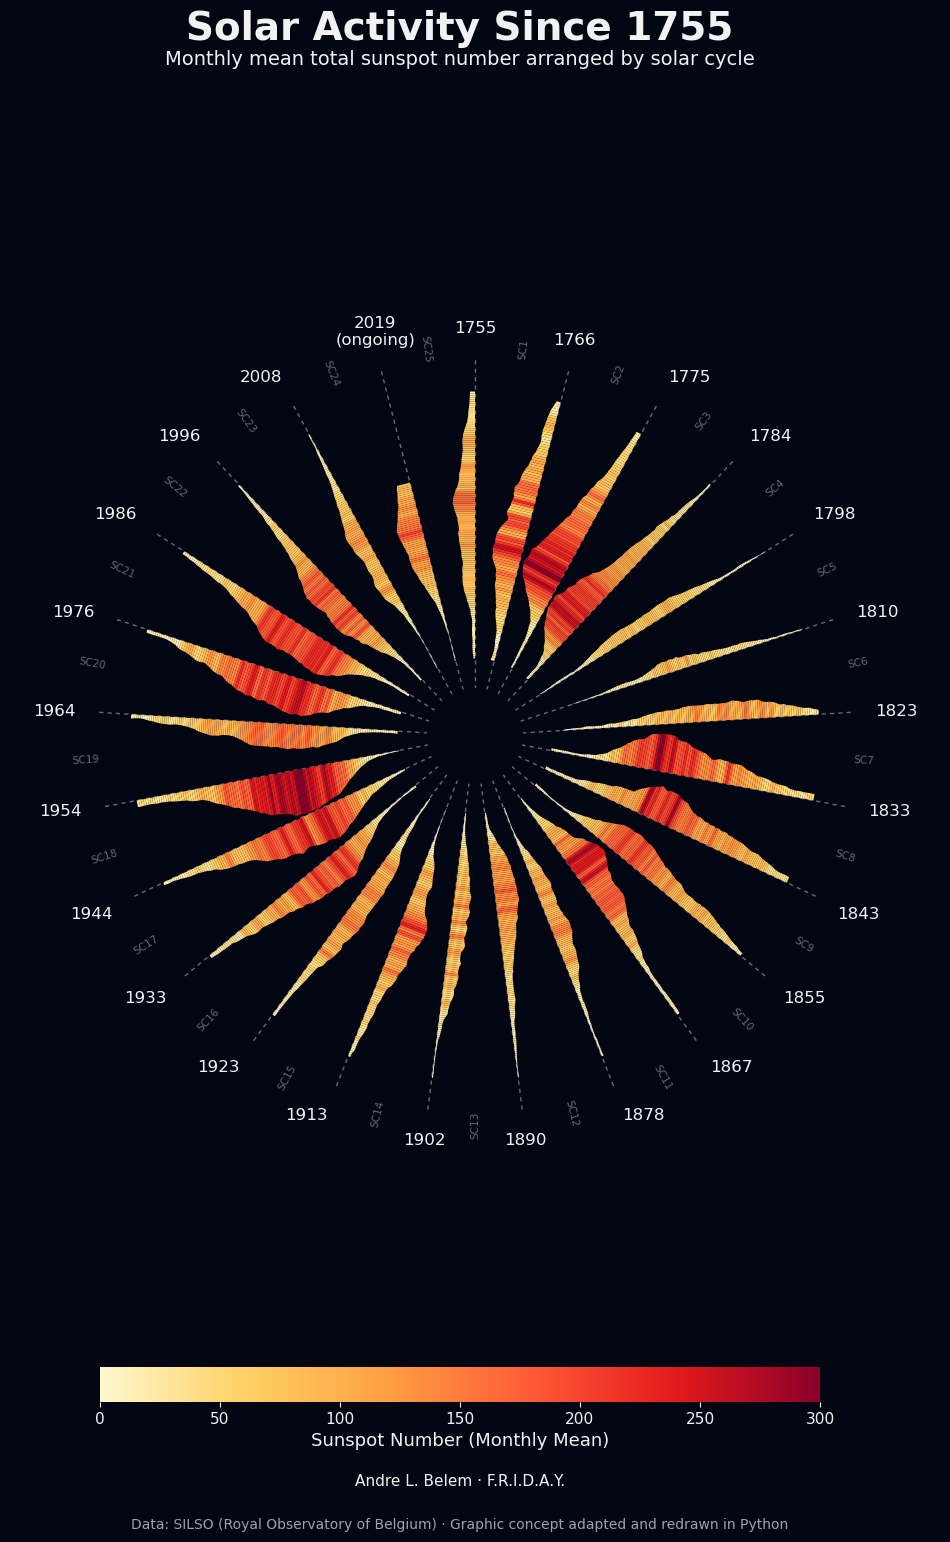

In [63]:
fig, ax = plot_solar_cycles_radial(df_cycles, CYCLE_START_YEARS)
plt.show()

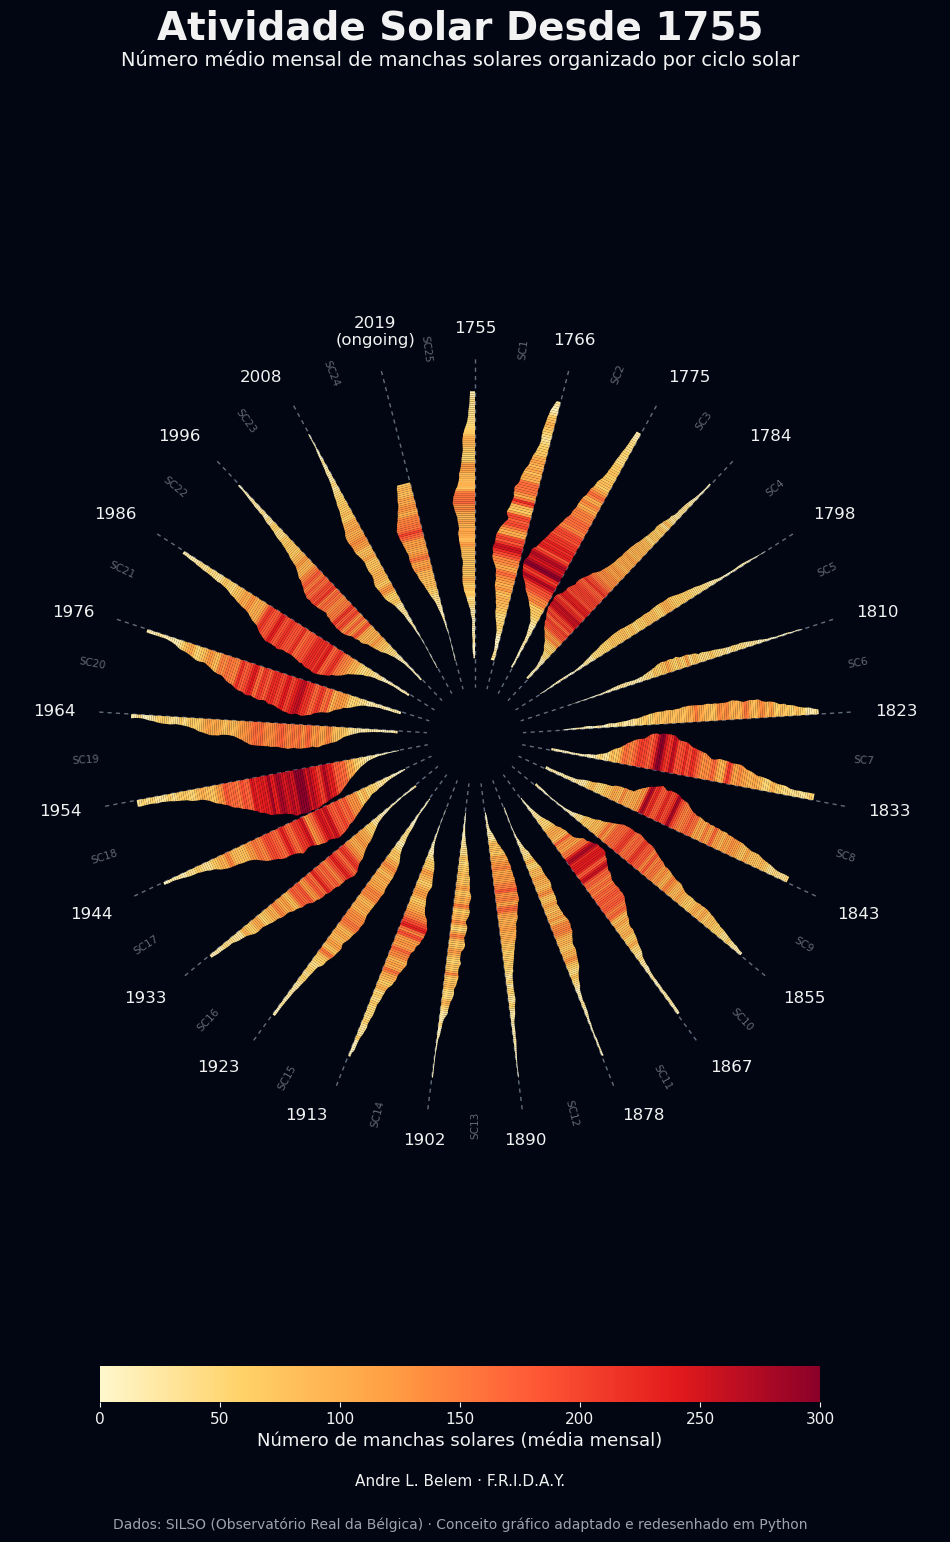

In [64]:
# Versão em português da figura
original_texts = (TITLE, SUBTITLE, COLORBAR_LABEL, AUTHOR_LINE, DATA_NOTE)

TITLE = "Atividade Solar Desde 1755"
SUBTITLE = "Número médio mensal de manchas solares organizado por ciclo solar"
COLORBAR_LABEL = "Número de manchas solares (média mensal)"
AUTHOR_LINE = "Andre L. Belem · F.R.I.D.A.Y."
DATA_NOTE = "Dados: SILSO (Observatório Real da Bélgica) · Conceito gráfico adaptado e redesenhado em Python"

fig_pt, ax_pt = plot_solar_cycles_radial(df_cycles, CYCLE_START_YEARS)
plt.show()

TITLE, SUBTITLE, COLORBAR_LABEL, AUTHOR_LINE, DATA_NOTE = original_texts


## 12. Salvar em múltiplos formatos

Abaixo salvamos a figura em formatos úteis para apresentação, edição vetorial e impressão.


In [65]:

out_png = OUTPUT_DIR / "solar_activity_since_1755_radial_curves.png"
out_svg = OUTPUT_DIR / "solar_activity_since_1755_radial_curves.svg"
out_pdf = OUTPUT_DIR / "solar_activity_since_1755_radial_curves.pdf"

fig.savefig(out_png, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
fig.savefig(out_svg, bbox_inches="tight", facecolor=fig.get_facecolor())
fig.savefig(out_pdf, bbox_inches="tight", facecolor=fig.get_facecolor())

print("Arquivos salvos em:")
print(out_png)
print(out_svg)
print(out_pdf)


Arquivos salvos em:
outputs_solar_cycles/solar_activity_since_1755_radial_curves.png
outputs_solar_cycles/solar_activity_since_1755_radial_curves.svg
outputs_solar_cycles/solar_activity_since_1755_radial_curves.pdf



## 13. Ajustes possíveis

Você pode experimentar várias modificações a partir deste ponto:

### A. Mais fidelidade temporal
- definir `NORMALIZE_CYCLE_LENGTH = False` para deixar a duração dos ciclos influenciar o comprimento radial.

### B. Curvas mais suaves
- aumentar `SMOOTHING_WINDOW` para 15 ou 17 meses;
- ou aplicar outro tipo de filtro (por exemplo, Savitzky–Golay, se desejar).

### C. Curvas mais “discretas”
- reduzir `AMPLITUDE_SCALE`;
- diminuir `linewidths` dentro da função `plot_solar_cycles_radial`.

### D. Visual mais editorial
- aumentar o contraste do título;
- ajustar tipografia;
- adicionar um subtítulo mais descritivo ou um bloco interpretativo.

### E. Variações científicas interessantes
- destacar ciclos específicos (por exemplo, Dalton Minimum ou ciclos recentes);
- sobrepor máximos de ciclo;
- acrescentar anéis de referência temporal;
- comparar a série mensal com uma série suavizada oficial.



## 14. Conclusão

Este notebook implementa a ideia discutida: **substituir a pétala por uma curva radial**, preservando a organização circular dos ciclos solares e reforçando a leitura como série temporal.

A figura resultante é uma base sólida para:

- uso didático;
- refinamento estético;
- adaptação para artigos, apresentações ou material de divulgação científica.

---

**Autoria:** Andre L. Belem & F.R.I.D.A.Y.
